# Taylor Approximation

**Goal.** Compare first- and second-order local approximations and measure their errors.
Verify convergence rates and extend to multivariate (gradient + Hessian) setting.


In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)


## WHAT

Near $a$, $f(a+h)\approx f(a)+f'(a)h+\frac12f''(a)h^2$. Gradient descent uses first-order information; Newton's method uses the quadratic model.

| Order | Approximation | Info used | ML analog |
|---|---|---|---|
| 0 | $f(a)$ | value | — |
| 1 | $f(a) + f'(a)h$ | value + gradient | Gradient descent |
| 2 | $f(a) + f'(a)h + \frac{1}{2}f''(a)h^2$ | value + gradient + curvature | Newton's method |


## Experiment 1: $f(x) = e^x$ at $a = 0.5$

All derivatives of $e^x$ equal $e^x$, so:
- 1st order: $e^a(1 + h)$
- 2nd order: $e^a(1 + h + h^2/2)$


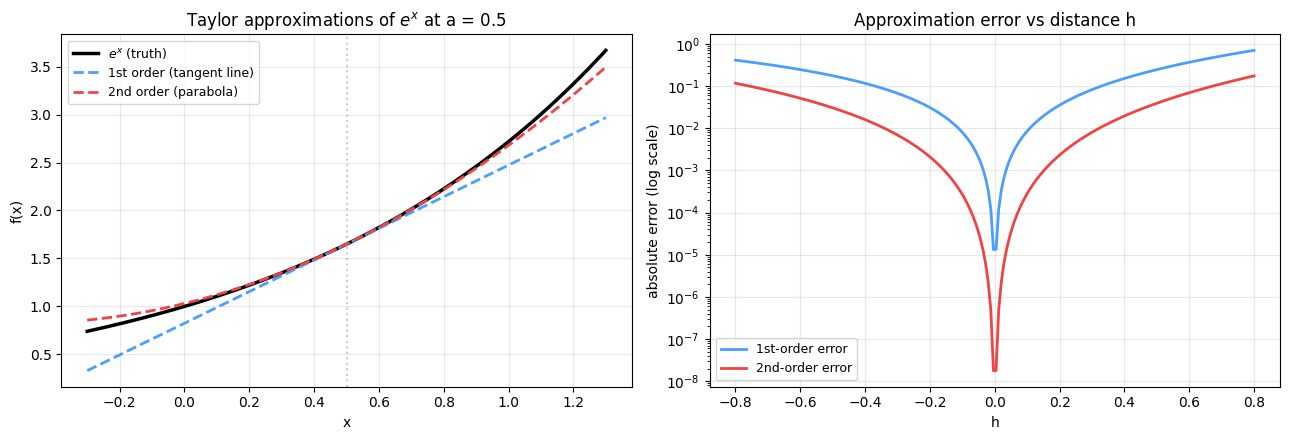

Mean error (|h|<0.1):  1st=0.002555  2nd=0.000062  ratio=41.5x


In [2]:
a = 0.5
h = np.linspace(-0.8, 0.8, 200)
truth = np.exp(a + h)
first_order = np.exp(a) * (1.0 + h)
second_order = np.exp(a) * (1.0 + h + 0.5 * h**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: function vs approximations
ax = axes[0]
ax.plot(a + h, truth, "k-", lw=2.5, label=r"$e^x$ (truth)")
ax.plot(a + h, first_order, "--", color="#4a9eff", lw=2, label="1st order (tangent line)")
ax.plot(a + h, second_order, "--", color="#ef4444", lw=2, label="2nd order (parabola)")
ax.axvline(a, color="gray", alpha=0.4, ls=":")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title(f"Taylor approximations of $e^x$ at a = {a}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: errors
ax = axes[1]
ax.plot(h, np.abs(truth - first_order), color="#4a9eff", lw=2, label="1st-order error")
ax.plot(h, np.abs(truth - second_order), color="#ef4444", lw=2, label="2nd-order error")
ax.set_yscale("log")
ax.set_xlabel("h")
ax.set_ylabel("absolute error (log scale)")
ax.set_title("Approximation error vs distance h")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

near = np.abs(h) < 0.1
mean_1st = np.mean(np.abs(truth[near] - first_order[near]))
mean_2nd = np.mean(np.abs(truth[near] - second_order[near]))
assert mean_2nd < mean_1st
print(f"Mean error (|h|<0.1):  1st={mean_1st:.6f}  2nd={mean_2nd:.6f}  ratio={mean_1st/mean_2nd:.1f}x")


## Convergence rate verification

Theory predicts: 1st-order error $\sim O(h^2)$, 2nd-order error $\sim O(h^3)$.
On a log-log plot, the slope should be 2 and 3 respectively.


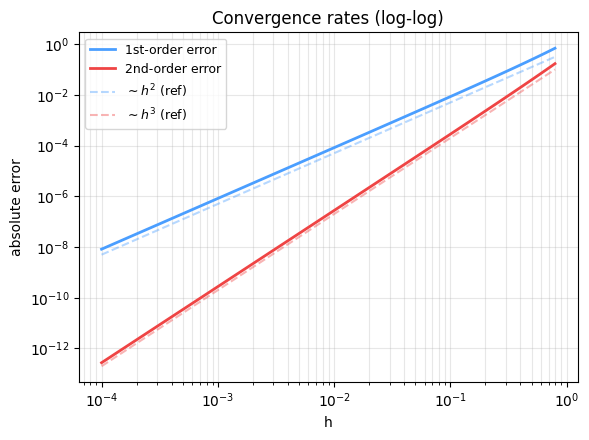

Measured slopes:  1st-order = 2.02 (expect ~2)  2nd-order = 3.01 (expect ~3)


In [3]:
h_pos = np.logspace(-4, -0.1, 100)  # positive h only for clean log-log
err_1 = np.abs(np.exp(a + h_pos) - np.exp(a) * (1.0 + h_pos))
err_2 = np.abs(np.exp(a + h_pos) - np.exp(a) * (1.0 + h_pos + 0.5 * h_pos**2))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(h_pos, err_1, color="#4a9eff", lw=2, label="1st-order error")
ax.loglog(h_pos, err_2, color="#ef4444", lw=2, label="2nd-order error")

# Reference slopes
ax.loglog(h_pos, 0.5 * h_pos**2, "--", color="#4a9eff", alpha=0.4, label=r"$\sim h^2$ (ref)")
ax.loglog(h_pos, 0.2 * h_pos**3, "--", color="#ef4444", alpha=0.4, label=r"$\sim h^3$ (ref)")

ax.set_xlabel("h")
ax.set_ylabel("absolute error")
ax.set_title("Convergence rates (log-log)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

# Numerical slope check via linear regression on log-log
log_h = np.log(h_pos)
slope_1 = np.polyfit(log_h, np.log(err_1), 1)[0]
slope_2 = np.polyfit(log_h, np.log(err_2), 1)[0]
print(f"Measured slopes:  1st-order = {slope_1:.2f} (expect ~2)  2nd-order = {slope_2:.2f} (expect ~3)")
assert 1.8 < slope_1 < 2.2, f"1st-order slope {slope_1:.2f} not near 2"
assert 2.8 < slope_2 < 3.2, f"2nd-order slope {slope_2:.2f} not near 3"


## Experiment 2: $f(x) = \sin(x)$ at $a = 1.0$

Different function to confirm generality. Here $f'(a)=\cos(a)$, $f''(a)=-\sin(a)$.


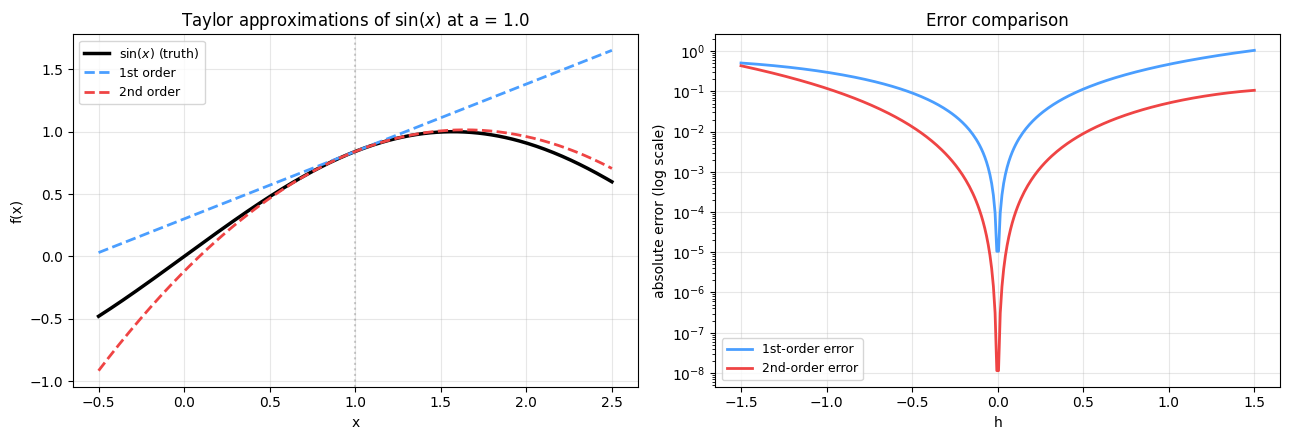

sin(x) — Mean error (|h|<0.1):  1st=0.001408  2nd=0.000023  ratio=62.2x


In [4]:
a2 = 1.0
h2 = np.linspace(-1.5, 1.5, 300)
truth2 = np.sin(a2 + h2)
first2 = np.sin(a2) + np.cos(a2) * h2
second2 = np.sin(a2) + np.cos(a2) * h2 - 0.5 * np.sin(a2) * h2**2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(a2 + h2, truth2, "k-", lw=2.5, label=r"$\sin(x)$ (truth)")
ax.plot(a2 + h2, first2, "--", color="#4a9eff", lw=2, label="1st order")
ax.plot(a2 + h2, second2, "--", color="#ef4444", lw=2, label="2nd order")
ax.axvline(a2, color="gray", alpha=0.4, ls=":")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title(f"Taylor approximations of $\\sin(x)$ at a = {a2}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(h2, np.abs(truth2 - first2), color="#4a9eff", lw=2, label="1st-order error")
ax.plot(h2, np.abs(truth2 - second2), color="#ef4444", lw=2, label="2nd-order error")
ax.set_yscale("log")
ax.set_xlabel("h")
ax.set_ylabel("absolute error (log scale)")
ax.set_title("Error comparison")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

near2 = np.abs(h2) < 0.1
m1 = np.mean(np.abs(truth2[near2] - first2[near2]))
m2 = np.mean(np.abs(truth2[near2] - second2[near2]))
assert m2 < m1
print(f"sin(x) — Mean error (|h|<0.1):  1st={m1:.6f}  2nd={m2:.6f}  ratio={m1/m2:.1f}x")


## Multivariate Taylor (2D)

For $f: \mathbb{R}^d \to \mathbb{R}$, the second-order expansion at $a$ is:

$$f(a + h) \approx f(a) + \nabla f(a)^\top h + \frac{1}{2} h^\top H_f(a)\, h$$

This connects directly to the Hessian in `derivatives_gradients.md`.
We use $f(x_1, x_2) = x_1^2 + 3x_2^2$ (a quadratic — Taylor is exact).


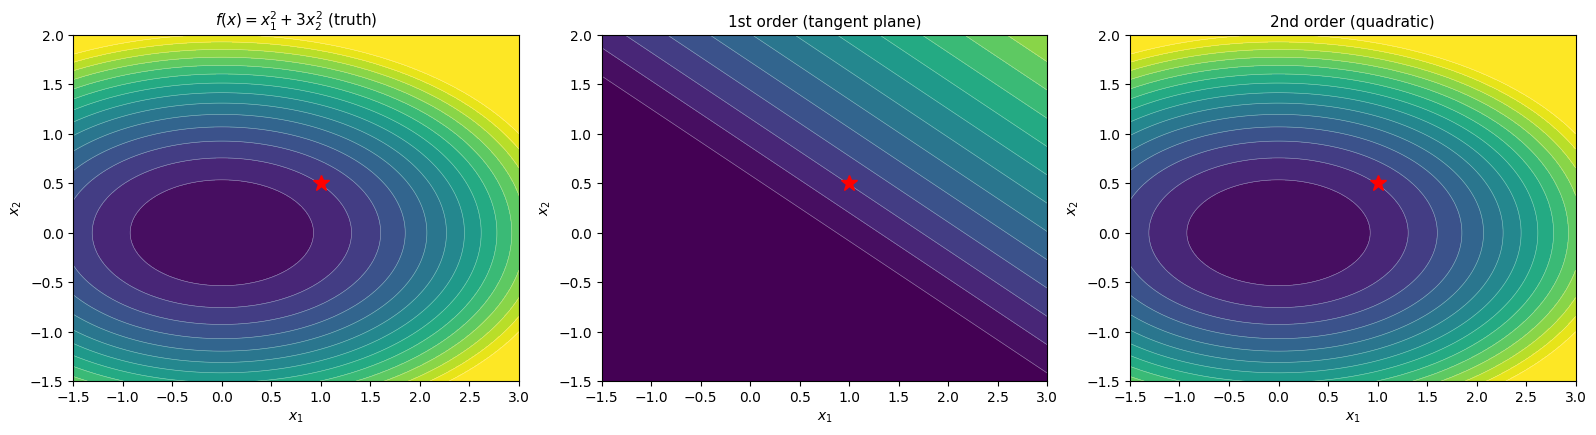

Max error — 1st order: 18.2500,  2nd order: 7.11e-15
Verified: 2nd-order Taylor is exact for quadratic functions.


In [5]:
def f_2d(x1, x2):
    return x1**2 + 3 * x2**2

def grad_2d(x1, x2):
    return np.array([2 * x1, 6 * x2])

H_2d = np.array([[2, 0],
                  [0, 6]])  # constant Hessian

# Expansion point
a_pt = np.array([1.0, 0.5])
f_a = f_2d(*a_pt)
g_a = grad_2d(*a_pt)

# Grid
x1 = np.linspace(-1.5, 3.0, 200)
x2 = np.linspace(-1.5, 2.0, 200)
X1, X2 = np.meshgrid(x1, x2)
Z_true = f_2d(X1, X2)

# Taylor approximations on grid
H1 = X1 - a_pt[0]  # displacement vectors
H2 = X2 - a_pt[1]
Z_1st = f_a + g_a[0] * H1 + g_a[1] * H2
Z_2nd = Z_1st + 0.5 * (H_2d[0, 0] * H1**2 + 2 * H_2d[0, 1] * H1 * H2 + H_2d[1, 1] * H2**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
levels = np.linspace(0, 12, 15)

for ax, Z, title in zip(axes,
                         [Z_true, Z_1st, Z_2nd],
                         [r"$f(x) = x_1^2 + 3x_2^2$ (truth)",
                          "1st order (tangent plane)",
                          "2nd order (quadratic)"]):
    cs = ax.contourf(X1, X2, Z, levels=levels, cmap="viridis", extend="both")
    ax.contour(X1, X2, Z, levels=levels, colors="white", linewidths=0.4, alpha=0.5)
    ax.plot(*a_pt, "r*", ms=12, zorder=5)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# For a quadratic, 2nd-order Taylor is exact everywhere
max_err_2nd = np.max(np.abs(Z_true - Z_2nd))
max_err_1st = np.max(np.abs(Z_true - Z_1st))
print(f"Max error — 1st order: {max_err_1st:.4f},  2nd order: {max_err_2nd:.2e}")
assert max_err_2nd < 1e-10, "2nd order should be exact for quadratics"
print("Verified: 2nd-order Taylor is exact for quadratic functions.")


## Result

1. Higher-order information improves the local model, verified by error ratios and convergence slopes.
2. 1st-order error scales as $O(h^2)$; 2nd-order as $O(h^3)$ — confirmed numerically.
3. For quadratics, 2nd-order Taylor is **exact** — this is why Newton's method converges in one step on quadratics.
4. Computing and solving with a Hessian can be expensive or unstable in high dimensions.
